# Pipeline B — Virality Predictor

## Plan

| Component | Choice | Citation |
| :--- | :--- | :--- |
| Virality target | K-means on log-normalised subreddit-median-normalised engagement (8.4% viral class) | Barnes et al. (2020); Dogan et al. (2026) |
| Data split | Fakeddit official random splits | Nakamura et al. (2019) |
| Structural metadata | Title word count, temporal (hour bin, day of week, is_weekend), hasImage, caps ratio, punctuation count | Barnes et al. (2020) |
| Domain credibility | MBFC bias and factuality ratings via Idiap Research Institute dataset | Grinberg et al. (2019) |
| Psycholinguistic | NRC EmoLex (8 emotions) + VADER compound — publisher emotion component only | Zhang et al. (2021); Giachanou et al. (2019); Mohammad & Turney (2013); Hutto & Gilbert (2014) |
| Veracity proxy | BERT softmax probabilities (p_true, p_fake_true_text, p_fake_false_text) from Pipeline A | Vosoughi et al. (2018) |
| Political leaning | Phase 1 Fakeddit: keyword density ratio. Phase 2 UK only: Antypas et al. trigger-word counts | Antypas et al. (2026) |
| Interaction term | p_fake x is_low_credibility_domain | Engineered |
| Baseline model | Random Forest | Barnes et al. (2020) |
| Main model | XGBoost with scale_pos_weight for class imbalance | Dogan et al. (2026) |
| Evaluation | PR-AUC (primary), ROC-AUC, F1 at optimal threshold, confusion matrix | Dogan et al. (2026) |
| Explainability | SHAP global summary and interaction plots | Lundberg & Lee (2017); Hashmi et al. (2024) |

## Notes

- Data split: Fakeddit official random splits used rather than chronological. Studying structural and linguistic characteristics that contribute to virality on a static snapshot, not predicting temporal diffusion. Must use same splits as Pipeline A to prevent cross-pipeline contamination.
- Political leaning: BART-MNLI dropped for Phase 1 — US political context unreliable for left/right classification and compute is prohibitive on 564k rows. Simple keyword density ratio used instead. BART-MNLI reserved for Phase 2 UK data only if time allows, otherwise Antypas trigger-word counts are sufficient.
- Social emotion component from Zhang et al. (2021) not implemented — Fakeddit provides comment counts but not comment text. Publisher emotion only. Noted as a limitation.
- Emotion inversion finding: label 0 (True) scores higher than label 2 (Fake/false text) on all emotion dimensions — artefact of label 2 being 85% image-manipulation subreddits with descriptive, emotionally flat captions. Not a theoretical failure. XGBoost contamination risk documented in limitations.
- BERT softmax probabilities from Pipeline A are the cross-pipeline intersection feature connecting Pipeline A and Pipeline B. Must load checkpoint and run inference before feature matrix is complete.
- Interaction term p_fake x is_low_credibility_domain explicitly engineered to make the SHAP attribution of the veracity-credibility interaction directly readable.

In [1]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.3 MB/s  0:00:00
  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached aiohappyeyeballs-2.6.2-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiohttp-3.14.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.3 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached appnope-0.1.4-py2.py3-none-any.whl.metadata (908 bytes)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached babel-2.18.0-py3-none-any.whl.metadata (2.2 kB)
  Using cached bertopic-0.17.4-py3-none-any.whl.metadata (24 kB)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata (2.5 kB)
  Using cached charset_normalizer-3.4.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
from datetime import datetime
from zoneinfo import ZoneInfo
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from tqdm import tqdm
from datasets import Dataset
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import subprocess
import time
from nrclex import NRCLex
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              average_precision_score, f1_score,
                              precision_recall_curve, ConfusionMatrixDisplay,
                              confusion_matrix)


from pathlib import Path
import xgboost
import shap

[HAMI-core Msg(404:140488594533696:libvgpu.c:839)]: Initializing.....
/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
data_dir = os.path.join('..', 'data', 'processed', 'US')

train_path = os.path.join(data_dir, 'multimodal_train.tsv')
val_path = os.path.join(data_dir, 'multimodal_validate.tsv')
test_path = os.path.join(data_dir, 'multimodal_test_public.tsv')

train_df = pd.read_csv(train_path, sep='\t')
val_df = pd.read_csv(val_path, sep='\t')
test_df = pd.read_csv(test_path, sep='\t')

In [4]:
train_df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


### 1. Virality target construction 

Was going to use VAI (Chauhan et al., 2025) but they rely on post **age**, which I don't have as I'm using static snapshots. Instead, employ the methodology of **Barnes et al. (2020)** from Dank or Not meme paper.

They use feature extraction and then run both random forest and gradient boost models on the fulll feature set. They also use a dataset that's extracted from pushift - same as Fakeddit and my UK dataset so it's a good match.

Highly cited paper (72 citations) so an authoritative source in the research space

Construct virality labels
- Populatiry metric based on upvotes and number of comments - community engagement 
- Chauhan et al. 2025 use upvotes + num_comments in their VAI equation, then divide by age (in hrs). Won't be accounting for age since my snapshot is static. 
- Following Barnes et al (2020), raw engagement scores are normalised to reduce impact of subreddit size. To show why this is necessary, can follow their analysis: "To confirm this observation, we determined the median number of upvotes for each respective subreddit and calculated a Pearson correlation coefficient between these values and the number of subscribers for each subreddit.". **My data doesn't have subreddit subscriber counts, so need to use an alternative method to account for community size. Divide by median raw engagement score for the post's subreddit (acts as proxy for subscriber scale**

`raw_engagement = score + num_comments`

`log_engagement = log(raw_engagement + 1)`

`normalised_engagement = (log_engagement - subreddit_log_mean) / subreddit_log_std`

Justification for raw engagement smoothing method:
- Answers question: how many standard deviations above or below typical is this post's engagement within its own community?
- Raw engagement follows a power law (heavy-tailed og distribution)
- Log transforming makes it approx **normally distributed**, making z-score normalisation valid. **Clip negative scores to 0 to ensure that log transform doesn't produce large negative values - log1p(-1) = -inf, log1p on < -1 = NaN**
- Also means that clustering is in units of standard deviations, which is easily interpretable. 
Follows standard practice for comparing observations across populations with different distributional parameters. Grounded in CLT

Virality threshold determined by k-means
- Following methodology of Dogan et al. 
- K = 2. Clustering algorithm deployed across whole dataset. Segmenting long-tailed distribution into two structural clusters - viral and non-viral. 
- Use 99th percentile outlier cap - k-menas heavily affected by extreme outliers. Apply cap to reduce their effect 
- Ensures threshold dictated by structure of user engagement data rather than unjustified empirical choice. 

In [5]:
def calculate_engagement_metric(df, train_percentile_cap=None, train_subreddit_stats=None):
    """
    Computes each reddit post's normalised engagement score using log z-score within subreddit

    Parameters 
    ----------
    train_percentile_cap : float, optional
        Pre-computed 99th percentile from training set.
        None = compute from this df (use only for train split).
    train_subreddit_stats : dict, optional
        Pre-computed {'mean': Series, 'std': Series} from training set.
        None = compute from this df (use only for train split).
    
    Returns 
    ----------
    df : DataFrame with engagement score column added
    cap_value : 99th percentile threshold (reuse for val/test)
    subreddit_stats : dict of train set subreddit means and stds 

    """

    df = df.copy()

    # raw engagement = num comments + score (num upvotes)
    df['raw_engagement'] = df['num_comments'].fillna(0).clip(lower=0) + df['score'].fillna(0).clip(lower=0)

    # log transform 
    df['log_raw_engagement'] = np.log1p(df['raw_engagement'])

    # z-score within subreddit 
    if train_subreddit_stats is None:   # must be train split to prevent data leakage  - computing threshold 
        sub_means = df.groupby(['subreddit'])['log_raw_engagement'].mean()
        sub_stds = df.groupby(['subreddit'])['log_raw_engagement'].std(ddof=0).fillna(0)
        subreddit_stats = {'mean': sub_means, 'std': sub_stds}
    else:
        subreddit_stats = train_subreddit_stats

    df['sub_mean'] = df['subreddit'].map(subreddit_stats['mean'])
    df['sub_std'] = df['subreddit'].map(subreddit_stats['std'])

    # handle subreddits unseen in training data - fill with total population stats
    df['sub_mean'] = df['sub_mean'].fillna(df['log_raw_engagement'].mean())
    df['sub_std'] = df['sub_std'].fillna(df['log_raw_engagement'].std())

    df['normalised_engagement'] = (df['log_raw_engagement'] - df['sub_mean'])/(df['sub_std'] + 1e-8) # add v small number to avoid dividing by zero when subreddits only have 1 post

    # apply percentile outlier cap to reduce the effects of outliers on k-means. Train set threshold applied to all splits
    if train_percentile_cap is None:
        cap_value = df['normalised_engagement'].quantile(0.99)
    else: 
        cap_value = train_percentile_cap

    df['capped_engagement'] = np.minimum(df['normalised_engagement'], cap_value) # use what's smaller of engagement number or percentile cap 

    # remove intermediate cols
    df = df.drop(columns=['sub_mean', 'sub_std'])
    
    return df, cap_value, subreddit_stats


In [6]:
def plot_engagement_dist(df, threshold):
    plot_df = pd.DataFrame({
        'Capped_Normalised_Engagement': df['capped_engagement'],
        'Class': df['is_viral'].map({0: "Non-Viral (0)", 1: 'Viral (1)'})
    })

    plt.figure(figsize=(8, 5))
    sns.set_theme(style='whitegrid')

    sns.histplot(
        data=plot_df,
        x='Capped_Normalised_Engagement',
        hue='Class',
        palette={'Non-Viral (0)': '#3498db', 'Viral (1)': '#e74c3c'},
        bins=50
    )

    # virality threshold line 
    plt.axvline(
        x=threshold, 
        color='#2c3e50',
        linestyle='--',
        linewidth=2.5,
        label=f'Virality Threshold ({threshold:.2f})'
    )

    plt.title('Data-Driven Virality Partitioning (Dogan et al. 2026 Framework)', fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Capped Normalised Engagement [ln(x + 1)]', fontsize=12, labelpad=10)
    plt.ylabel('Post Count (Frequency)', fontsize=12, labelpad=10)

    plt.legend(title='Class', title_fontsize='11', loc='upper right', frameon=True)

    plt.tight_layout()
    plt.show()



In [7]:
def calculate_engagement_threshold_k_means(df, train_percentile_cap=None, train_subreddit_stats=None, train_threshold=None, graph=True):
    """
    Computes binary virality threshold based on k-means clustering on normlaised engagement score 
    """

    df, cap_value, subreddit_stats = calculate_engagement_metric(
        df,
        train_percentile_cap=train_percentile_cap,
        train_subreddit_stats=train_subreddit_stats
        )
    
    engagement_values = df['capped_engagement'].values

    if train_threshold is None: 
        # For TRAIN set - fit K-means to find virality boundary
        # reshape for scikit-learn
        engagement_matrix = engagement_values.reshape(-1, 1)

        # train k-means with 2 clusters - viral vs non-viral
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        df['cluster_labels'] = kmeans.fit_predict(engagement_matrix)

        # map cluster labels to 'is_viral' df col
        cluster_centres = kmeans.cluster_centers_.flatten()
        viral_clusters = np.argmax(cluster_centres)     # seeing which cluster has the higher engagement metrics

        df['is_viral'] = (df['cluster_labels'] == viral_clusters).astype(int)

        threshold = np.mean(cluster_centres)
        print(f'K-means virality threshold: {threshold:.4f}')
    
    else: 
        # VAL/TEST - apply training threshold, do not refit 
        threshold = train_threshold
        df['is_viral'] = (df['capped_engagement'] >= threshold).astype(int)
        print(f'Applied training threshold: {threshold:.4f}')

    print(f'Class distribution: {df['is_viral'].value_counts(normalize=True).round(3).to_dict()}')

    if graph:
        plot_engagement_dist(df, threshold)


    cols_to_drop = ['cluster_labels', 'log_raw_engagement', 'capped_engagement', 'raw_engagement']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df, threshold, cap_value, subreddit_stats

- Initially applied 99% cap as done in paper, but viral class too small, too still heavily affected by outliers. Acute class imbalance would make downstream supervised learning difficult (justify)
- To further smooth the long tail variance, a natural log transformation was applied (ln(x+1))

K-means virality threshold: 0.4990
Class distribution: {0: 0.77, 1: 0.23}


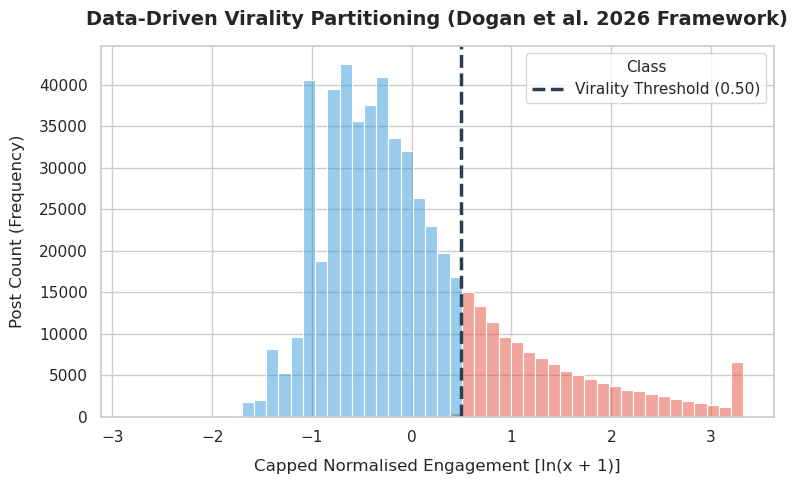

In [8]:
train_df, threshold, cap_value, sub_stats = calculate_engagement_threshold_k_means(train_df, graph=True)

Can't justify using k means clustering on the z-normlaised dataset because it is unomodal and there's no clear threshold. Would only need a raw engagement score of arround 55 to be 'viral' - too low. Instead, revert to the top 20% threshold used by Barnes et al. (sp this approach is consistent with prior work in social media virality prediction)

- Produces a class balance suitable for supervised learning 
- z-score normalisation accounts for varied subreddit community sizes

**DROP K MEANS**


In [9]:
def apply_virality_threshold(df, train_percentile_cap=None,
                              train_subreddit_stats=None,
                              train_threshold=None,
                              viral_percentile=0.80,
                              graph=True):
    df, cap_value, subreddit_stats = calculate_engagement_metric(
        df,
        train_percentile_cap=train_percentile_cap,
        train_subreddit_stats=train_subreddit_stats,
    )

    if train_threshold is None:
        threshold = df['capped_engagement'].quantile(viral_percentile)
    else:
        threshold = train_threshold

    df['is_viral'] = (df['capped_engagement'] >= threshold).astype(int)

    print(f'Virality threshold (z-score): {threshold:.4f}')
    print(f'Class distribution:\n{df["is_viral"].value_counts(normalize=True).round(3)}')

    if graph:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        df['capped_engagement'].hist(bins=100, ax=axes[0])
        axes[0].axvline(threshold, color='red', linestyle='--',
                        label=f'threshold={threshold:.2f}')
        axes[0].set_title('Normalised engagement distribution')
        axes[0].set_xlabel('z-score (capped)')
        axes[0].legend()

        df['log_raw_engagement'].hist(bins=100, ax=axes[1])
        axes[1].set_title('Log raw engagement distribution')
        axes[1].set_xlabel('log(raw_engagement + 1)')

        plt.tight_layout()
        plt.show()

        overall_mean = df['log_raw_engagement'].mean()
        overall_std  = df['log_raw_engagement'].std()
        approx_raw_eng = np.expm1(threshold * overall_std + overall_mean)
        print(f"Approx raw engagement at threshold: {approx_raw_eng:.0f} (upvotes + comments)")

    # drop intermediate columns after plotting
    df = df.drop(columns=[c for c in ['capped_engagement', 'log_raw_engagement',
                                       'raw_engagement'] if c in df.columns])

    return df, threshold, cap_value, subreddit_stats

Apply threshold calculated on training set to validation and test sets. Important that threshold is not recalculated so that there is no data leakage in the pipeline. No info from the test set influences the definition of virality. 

Virality threshold (z-score): 0.6384
Class distribution:
is_viral
0    0.8
1    0.2
Name: proportion, dtype: float64


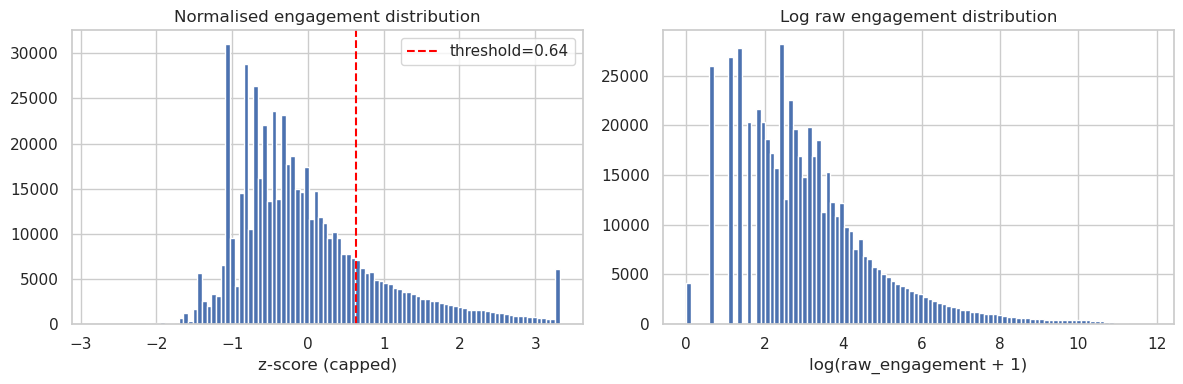

Approx raw engagement at threshold: 71 (upvotes + comments)


In [10]:
train_df, threshold, cap_value, sub_stats = apply_virality_threshold(
    train_df, graph=True
)

Virality threshold (z-score): 1.3551
Class distribution:
is_viral
0    0.9
1    0.1
Name: proportion, dtype: float64


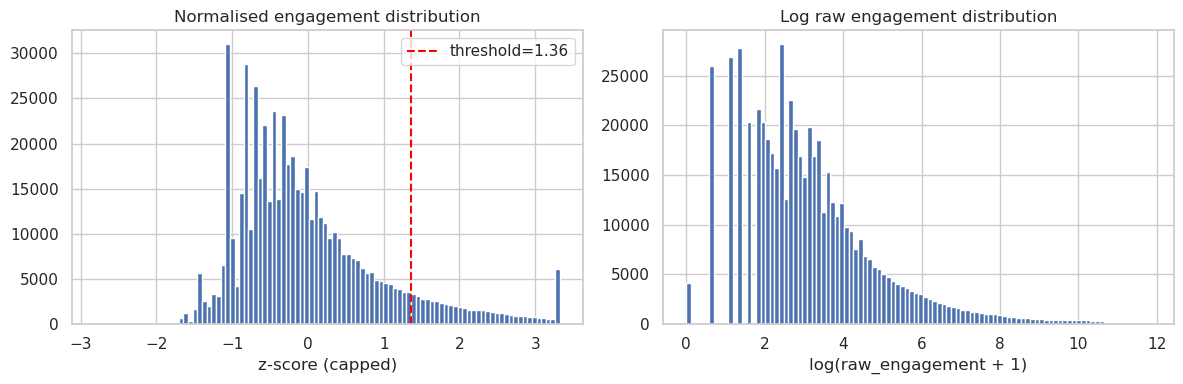

Approx raw engagement at threshold: 252 (upvotes + comments)


In [11]:
train_df, threshold, cap_value, sub_stats = apply_virality_threshold(
    train_df, viral_percentile=0.90, graph=True
)

In [12]:
val_df, _, _, _ = apply_virality_threshold(
    val_df,
    train_percentile_cap=cap_value,
    train_subreddit_stats=sub_stats,
    train_threshold=threshold,
    graph=False,
)

test_df, _, _, _ = apply_virality_threshold(
    test_df,
    train_percentile_cap=cap_value,
    train_subreddit_stats=sub_stats,
    train_threshold=threshold,
    graph=False,
)

Virality threshold (z-score): 1.3551
Class distribution:
is_viral
0    0.9
1    0.1
Name: proportion, dtype: float64
Virality threshold (z-score): 1.3551
Class distribution:
is_viral
0    0.898
1    0.102
Name: proportion, dtype: float64


In [13]:
artefacts = {
    'threshold': threshold,
    'cap_value': cap_value,
    'viral_percentile': 0.80,
    'sub_stats_mean': sub_stats['mean'].to_dict(),
    'sub_stats_std': sub_stats['std'].to_dict(),
}

Path('../data/processed/US').mkdir(parents=True, exist_ok=True)
with open('../data/processed/US/virality_artefacts.json', 'w') as f:
    json.dump(artefacts, f, indent=2)
print('Artefacts saved')

Artefacts saved


**Virality target — final summary**
- Normalisation: log z-score within subreddit (clip scores to 0, ddof=0 std)
- Outlier cap: 99th percentile from training set
- Threshold: 90th percentile of normalised engagement on training set
  (z = 1.36, approx raw engagement = 252 upvotes + comments)
- Class distribution: 90% non-viral, 10% viral (consistent across splits)
- Justification: a z-score threshold of ~1.36 places the virality boundary 
  at more than one standard deviation above the subreddit mean, consistent 
  with the statistical definition of an exceptional observation. The 90th 
  percentile operationalises this: viral posts are those in the top decile 
  of normalised engagement within their community.
- K-means rejected: distribution is unimodal — degenerates to median split
- Barnes et al. (2020) use a top-5% threshold; I'm using a top-10% 
  definition to ensure the viral class captures genuinely exceptional 
  engagement rather than posts that just have above-average engagement (z score of around 1.35). **DO I NEED TO CHANGE THIS TO 5%????**

### 2. Feature engineering

Extracting additional features to enrich dataset and allow for discussion of factors leading to virality.

Already have binary true/fake misinofrmation flag from the labelled fakeddit dataset for US. If found to be an important feature, the BERT model I've trained will br used to extract these labels for UK data. 

#### 2.1 Structural Metadata

**Temporal metadata**

Controls for time-based cycles Reddit platform traffic and user engagement


Following methodology of Dank or Not (Barnes et al.). Timestamp for when post first appeared on Reddit is in the Coordinated Universal Time zone (UTC). For Fakeddit, assume majority of posts created in US, so convert to North American Central Time zone, as they do in paper. For UK subreddits, convert to GMT. 

Then extract
- Time of day (in 4 hour bins)
- Day of week 
- Is weekend flag

In [ ]:
def add_temporal_features(utc_val, timezone='Europe/London'):
    dt = datetime.fromtimestamp(utc_val, tz=ZoneInfo('UTC'))
    local_dt = dt.astimezone(tz=ZoneInfo(timezone))
    return pd.Series({
        'day_of_week': local_dt.weekday(),           # 0=Mon, 6=Sun
        'is_weekend':  int(local_dt.weekday() >= 5), # 1 if Sat/Sun
        'time_of_day': local_dt.hour // 4,           # 0-5 integer bin
    })

for df in [train_df, val_df, test_df]:
    df[['day_of_week', 'is_weekend', 'time_of_day']] = \
        df['created_utc'].apply(add_temporal_features, args=('Europe/London',))

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,...,title,upvote_ratio,2_way_label,3_way_label,6_way_label,normalised_engagement,is_viral,day_of_week,is_weekend,time_of_day
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,...,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0,-0.396417,0,6,True,12 pm-4 pm
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,...,This concerned sink with a tiny hat,0.99,0,2,2,1.334576,0,6,True,8 pm-12 am
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,...,Hackers leak emails from UAE ambassador to US,0.92,1,0,0,0.316272,0,5,True,12 pm-4 pm
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,...,PsBattle: Puppy taking in the view,0.95,1,0,0,1.275603,0,1,False,4 am-8 am
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,...,I found a face in my sheet music too!,0.84,0,2,2,0.008301,0,2,False,8 pm-12 am


Text(0.5, 0, 'Normalised Engagement Score')

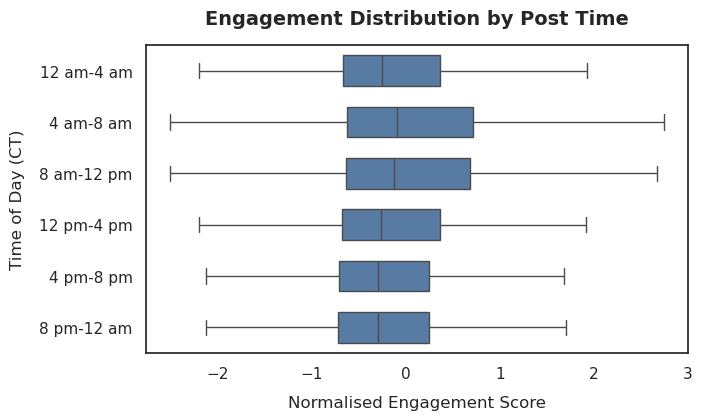

In [16]:
bin_labels = {
    0: '12 am-4 am',
    1: '4 am-8 am',
    2: '8 am-12 pm',
    3: '12 pm-4 pm',
    4: '4 pm-8 pm',
    5: '8 pm-12 am'
}

bin_order = ['12 am-4 am', '4 am-8 am', '8 am-12 pm', '12 pm-4 pm', '4 pm-8 pm','8 pm-12 am']

sns.set_theme(style='white')
plt.figure(figsize=(7,4))

ax = sns.boxplot(
    data=train_df,
    x='normalised_engagement',
    y='time_of_day',
    color='#4A7BB0',
    width=0.6,
    showfliers=False,
    order=bin_order
)

plt.title('Engagement Distribution by Post Time', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Time of Day (CT)', fontsize=12, labelpad=10)
plt.xlabel('Normalised Engagement Score', fontsize=12, labelpad=10)



**HasImage (Adapting Barnes et al., 2020):** Incorporate `hasImage` binary flag - native to Fakeddit but not to pushift dumps used for UK. Can engineer for UK - mark post as HasImage = 1 if url col includes an image extension (.jpg, .jpeg, .png, .gif) or if post_hint = image. Otherwise 0


**Word count**

Number of words in Fakeddit `clean title` column


In [17]:
def get_title_word_count(df, column):
    df['title_word_count'] = df.loc[:, column].str.split().str.len()

    return df

for df in [train_df, val_df, test_df]:
    df = get_title_word_count(df, 'clean_title')
train_df.head()


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,...,upvote_ratio,2_way_label,3_way_label,6_way_label,normalised_engagement,is_viral,day_of_week,is_weekend,time_of_day,title_word_count
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,...,0.84,1,0,0,-0.396417,0,6,True,12 pm-4 pm,15
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,...,0.99,0,2,2,1.334576,0,6,True,8 pm-12 am,7
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,...,0.92,1,0,0,0.316272,0,5,True,12 pm-4 pm,8
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,...,0.95,1,0,0,1.275603,0,1,False,4 am-8 am,5
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,...,0.84,0,2,2,0.008301,0,2,False,8 pm-12 am,9


**Processed text**

As in Dank or Not paper, all text associated with the post (for Fakeddit this is just `cleaned text`) undergoes tokenisation, lemmatisation, and stemming. Paper uses NTLK and emsim - references Rehurek and Sojka 2011; Loper and Bird 2002

In [18]:
def clean_and_stem_text(text):
    if not isinstance(text, str):
        return []
    
    # lowercase and remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    # tokenise and remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in text.split() if word not in stop_words]
    # stemming (same as Barnes et al.)
    stemmer = PorterStemmer()
    return [stemmer.stem(token) for token in tokens]

In [19]:
train_df['processed_words'] = train_df['clean_title'].apply(clean_and_stem_text)

**Domain Credibility**

Cross check domains against verfied lost of websites and heir credibility ratings. Use MBFC (Media Bias Fact Check - https://mediabiasfactcheck.com/) official ratings for `bias` and `factual reporting`. CSV is from Idiap Research Institute's github - from paper **Mapping the Media Landscape: Predicting Factual Reporting and Political Bias Through Web Interactions**

In [20]:
# load MBFC dataset
idiamap_mbfc_url = 'https://raw.githubusercontent.com/idiap/Factual-Reporting-and-Political-Bias-Web-Interactions/main/data/mbfc.csv'
mbfc_df = pd.read_csv(idiamap_mbfc_url)
mbfc_df.head()


,source,bias,factual_reporting
0,9news.com,neutral,high
1,nbc11news.com,neutral,high
2,12news.com,neutral,high
3,wibw.com,neutral,high
4,wifr.com,neutral,high


In [21]:
# check uk domains present 
uk_targets = ['theguardian.com', 'independent.co.uk', 'gbnews.uk', 'bbc.co.uk', 'dailymail.co.uk']
uk_check = mbfc_df[mbfc_df['source'].isin(uk_targets)]
print(uk_check)

# check major us domains present
us_targets = ['nytimes.com', 'foxnews.com', 'breitbart.com', 'washingtonpost.com', 'thegatewaypundit.com']
us_check = mbfc_df[mbfc_df['source'].isin(us_targets)]
print(us_check)

                 source         bias factual_reporting
1704    theguardian.com  left-center             mixed
1708  independent.co.uk  left-center             mixed
1722    theguardian.com  left-center             mixed
2764    dailymail.co.uk        right               low
2868          gbnews.uk        right             mixed
                    source         bias factual_reporting
1600           nytimes.com  left-center              high
1806    washingtonpost.com  left-center             mixed
2681         breitbart.com        right             mixed
2854           foxnews.com        right             mixed
3370  thegatewaypundit.com        right               low


One-hot encode mbfc columns so that they can be used in the feature matrix for XGBoost

In [22]:
# add MBFC domain credibility features to all three splits

# clean source column in MBFC lookup table
mbfc_df['source_clean'] = (mbfc_df['source']
                           .str.lower()
                           .str.strip()
                           .str.replace('www.', '', regex=False))

bias_map        = dict(zip(mbfc_df['source_clean'], mbfc_df['bias']))
factuality_map  = dict(zip(mbfc_df['source_clean'], mbfc_df['factual_reporting']))

NATIVE_REDDIT_DOMAINS = {'reddit.com', 'v.redd.it', 'i.redd.it', 'i.imgur.com'}

def add_mbfc_features(df, bias_map, factuality_map, split_name=''):
    df = df.copy()

    # clean domain for matching
    df['domain_clean'] = (df['domain']
                          .str.lower()
                          .str.strip()
                          .str.replace('www.', '', regex=False))

    # map bias and factuality
    df['mbfc_bias']       = df['domain_clean'].map(bias_map).fillna('unknown_unrated')
    df['mbfc_factuality'] = df['domain_clean'].map(factuality_map).fillna('unknown_unrated')

    # override with native_reddit where applicable
    is_native = (
        df['domain_clean'].str.contains(r'self\.', na=False) |
        df['domain_clean'].isin(NATIVE_REDDIT_DOMAINS)
    )
    df.loc[is_native, ['mbfc_bias', 'mbfc_factuality']] = 'native_reddit'

    # value counts for sparsity notes
    print(f"{split_name} ({len(df):,} rows)")
    print("mbfc_bias:")
    print(df['mbfc_bias'].value_counts().to_string())
    print("\nmbfc_factuality:")
    print(df['mbfc_factuality'].value_counts().to_string())
    rated = (~df['mbfc_bias'].isin(['unknown_unrated', 'native_reddit'])).sum()
    print(f"\nPosts with MBFC rating: {rated:,} ({100*rated/len(df):.1f}%)")
    print(f"Posts without rating:   {len(df)-rated:,} ({100*(len(df)-rated)/len(df):.1f}%)\n")

    # one-hot encode bias
    df['bias_left']         = (df['mbfc_bias'] == 'left').astype(int)
    df['bias_left_center']  = (df['mbfc_bias'] == 'left-center').astype(int)
    df['bias_neutral']      = (df['mbfc_bias'] == 'neutral').astype(int)
    df['bias_right_center'] = (df['mbfc_bias'] == 'right-center').astype(int)
    df['bias_right']        = (df['mbfc_bias'] == 'right').astype(int)

    # one-hot encode factuality
    df['factuality_high']  = (df['mbfc_factuality'] == 'high').astype(int)
    df['factuality_mixed'] = (df['mbfc_factuality'] == 'mixed').astype(int)
    df['factuality_low']   = (df['mbfc_factuality'] == 'low').astype(int)

    # drop intermediate columns — keep raw strings for reference until confirmed
    df.drop(columns=['domain_clean', 'mbfc_bias', 'mbfc_factuality'], inplace=True)

    return df


train_df = add_mbfc_features(train_df, bias_map, factuality_map, split_name='train')
val_df   = add_mbfc_features(val_df,   bias_map, factuality_map, split_name='val')
test_df  = add_mbfc_features(test_df,  bias_map, factuality_map, split_name='test')

train (564,000 rows)
mbfc_bias:
mbfc_bias
unknown_unrated    258328
native_reddit      253443
left-center         27513
neutral             12210
left                 4635
right-center         4481
right                3390

mbfc_factuality:
mbfc_factuality
unknown_unrated    258328
native_reddit      253443
high                34046
mixed               17383
low                   800

Posts with MBFC rating: 52,229 (9.3%)
Posts without rating:   511,771 (90.7%)

val (59,342 rows)
mbfc_bias:
mbfc_bias
unknown_unrated    27389
native_reddit      26586
left-center         2792
neutral             1311
left                 475
right-center         439
right                350

mbfc_factuality:
mbfc_factuality
unknown_unrated    27389
native_reddit      26586
high                3507
mixed               1775
low                   85

Posts with MBFC rating: 5,367 (9.0%)
Posts without rating:   53,975 (91.0%)

test (59,319 rows)
mbfc_bias:
mbfc_bias
unknown_unrated    27063
native_reddit   

Majority of posts are `unknown_unrated` or `native_reddit` - accounts for over 90% of training data. For US data, these signals may be weak - could be different for UK. Need to bear sparsity in mind 

In [23]:
train_df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,...,title_word_count,processed_words,bias_left,bias_left_center,bias_neutral,bias_right_center,bias_right,factuality_high,factuality_mixed,factuality_low
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,...,15,"[walgreen, offbrand, mucinex, engrav, letter, ...",0,0,0,0,0,0,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,...,7,"[concern, sink, tini, hat]",0,0,0,0,0,0,0,0
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,...,8,"[hacker, leak, email, uae, ambassador, us]",0,1,0,0,0,0,1,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,...,5,"[puppi, take, view]",0,0,0,0,0,0,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,...,9,"[found, face, sheet, music]",0,0,0,0,0,0,0,0


#### 2.2 Psycholinguistic features

**Research question:** do misinformation posts go viral for different emotional reasons than factual posts? → requires emotional granularity, not just polarity

**Why not Barnes et al. approach?**
- Barnes et al. (2020) use Liu & Zhang (2012) opinion lexicon → coarse positive/negative/neutral only
- Cannot distinguish anger vs fear vs disgust → SHAP analysis would be uninterpretable

**Framework: Zhang et al. (2021, WWW) — "Mining Dual Emotion for Fake News Detection"**
- Most cited recent framework for emotion + fake news
- Publisher emotion (post text) + social emotion (comments) → dual emotion
- Social emotion and emotion gap shown to matter more than publisher emotion alone
- **Implementing publisher emotion component only** — Fakeddit has comment counts but not comment text, so social emotion is unavailable. Noted as a limitation.
- Publisher emotion features in Zhang et al.: emotion category, emotional lexicon, emotional intensity, sentiment score, auxiliary (punctuation/caps)
- Implementing **emotional lexicon** (EmoLex) + **sentiment score** (VADER) components — sufficient for tabular XGBoost feature matrix without additional classifiers

**Tool 1 — NRC Word-Emotion Association Lexicon (EmoLex; Mohammad & Turney, 2013)**
- 8 discrete emotions: anger, fear, joy, trust, disgust, sadness, anticipation, surprise
- Returns proportion of matched words per emotion (`affect_frequencies`) — already normalised by word count
- Granularity enables SHAP to distinguish which specific emotions drive viral misinfo vs viral truth
- Used in Giachanou et al. (2019, SIGIR) for credibility detection — directly justifies lexicon choice
- Vosoughi et al. (2018): false news triggers fear, disgust, surprise; true news triggers joy, trust, anticipation → theoretical motivation for these specific dimensions

**Tool 2 — VADER compound sentiment score (Hutto & Gilbert, 2014)**
- Single compound score [-1, 1]
- Designed for social media text — handles capitalisation, punctuation, slang
- Complements EmoLex: captures aggregate valence where EmoLex has no lexicon match (e.g. political proper nouns "Starmer", "NHS", "Brexit" return zero NRC scores but VADER scores surrounding language)
- Implements Zhang et al.'s sentiment score component

**Citation roles**
- Zhang et al. (2021, WWW) — framework being implemented (publisher emotion, emotional lexicon + sentiment score)
- Giachanou et al. (2019, SIGIR) — theoretical justification that granular emotion categories outperform sentiment polarity for credibility detection; uses EmoLex directly
- Mohammad & Turney (2013) — NRC EmoLex tool citation
- Hutto & Gilbert (2014) — VADER tool citation
- Vosoughi et al. (2018, Science) — theoretical motivation: false news is more emotionally charged and propagates differently from true news across all valence dimensions

**Note on Giachanou et al. citation:** their implementation is architectural (LSTM), not tabular — cite for theoretical motivation and lexicon justification only, not for the specific feature engineering approach

In [24]:
vader = SentimentIntensityAnalyzer()

# 8 emotions from EmoLex
nrc_emotions = ['anger', 'fear', 'joy', 'trust', 'disgust', 'sadness', 'anticipation', 'surprise']

_nrc = NRCLex()

def extract_emotion_features(text):
    """
    Extract NRC Emolex emotion proportions (col 0-1 for each emotion) and VADER compound sentiment (-1 to 1)

    """

    # account for empty/null input
    if not isinstance(text, str) or not text.strip():
        return {f'emo_{e}': 0.0 for e in nrc_emotions} | {'vader_component': 00}


    _nrc.load_raw_text(text)
    freq = _nrc.affect_frequencies # proportion 0-1 for each emotion 


    vs = vader.polarity_scores(text)

    return (
        {f'emo_{e}': freq.get(e, 0) for e in nrc_emotions} | 
        {'vader_compound': vs['compound']}
    )

In [25]:
# Check to see if outputs look sensible before full run 

spot_check_texts = [
    "Starmer slammed for betraying working class voters",
    "Government announces record NHS funding boost",
    "Rioters attack mosque in shocking scenes of violence",
    "Study finds immigrants commit more crime says report",
    "Local charity raises money for flood victims",
    "",    # empty — should return all zeros
    None,  # null — should return all zeros
]
 
print("Check: emotion features on sample titles\n")
for text in spot_check_texts:
    feats = extract_emotion_features(text)
    nonzero = {k: round(v, 3) for k, v in feats.items() if v != 0.0}
    print(f"  Text: {repr(str(text)[:60])}")
    print(f"  Non-zero features: {nonzero}\n")

Check: emotion features on sample titles

  Text: 'Starmer slammed for betraying working class voters'
  Non-zero features: {'vader_compound': -0.542}

  Text: 'Government announces record NHS funding boost'
  Non-zero features: {'vader_compound': 0.402}

  Text: 'Rioters attack mosque in shocking scenes of violence'
  Non-zero features: {'emo_anger': 0.375, 'emo_fear': 0.25, 'emo_sadness': 0.125, 'vader_compound': -0.872}

  Text: 'Study finds immigrants commit more crime says report'
  Non-zero features: {'emo_anger': 0.333, 'emo_fear': 0.333, 'vader_compound': -0.38}

  Text: 'Local charity raises money for flood victims'
  Non-zero features: {'emo_anger': 0.154, 'emo_fear': 0.154, 'emo_joy': 0.154, 'emo_trust': 0.077, 'emo_sadness': 0.077, 'emo_anticipation': 0.077, 'emo_surprise': 0.077, 'vader_compound': 0.128}

  Text: ''
  Non-zero features: {}

  Text: 'None'
  Non-zero features: {}



Demonstrates limitiation of EmoLex - operates at word level, doesn't use overall context of text. Local charity raises money for flood victims is positive but 'flood' and 'victims' result in fear and anger scores.

Scores won't necessarily sum to 1 - `affect_frequencies` normalises by total word count in text, so if only 6 out of 9 words in the title match an emotion in the lexicon, the resulting emotion proportions will only add to 0.66

In [26]:
text_col = 'clean_title'

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'Processing {name}: {len(df)} rows')
    start = time.time()

    emo_features = pd.DataFrame(
        df[text_col].apply(extract_emotion_features).tolist(),
        index=df.index
    )

    # join emo features back to original df
    for col in emo_features.columns:
        df[col] = emo_features[col]
    
    end = time.time()
    elapsed = end - start
    print(f'Finished in {elapsed:2f}s')

emo_cols = [f'emo_{e}' for e in nrc_emotions] + ['vader_compound']
print(f"\nNew columns: {emo_cols}")
print(f"\nTrain set — mean emotion scores:")
print(train_df[emo_cols].mean().round(4).to_string())
print(f"\nNull counts: {train_df[emo_cols].isnull().sum().sum()} (should be 0)")

Processing train: 564000 rows
Finished in 88.710853s
Processing val: 59342 rows
Finished in 9.193063s
Processing test: 59319 rows
Finished in 9.098847s

New columns: ['emo_anger', 'emo_fear', 'emo_joy', 'emo_trust', 'emo_disgust', 'emo_sadness', 'emo_anticipation', 'emo_surprise', 'vader_compound']

Train set — mean emotion scores:
emo_anger           0.0366
emo_fear            0.0563
emo_joy             0.0477
emo_trust           0.0808
emo_disgust         0.0266
emo_sadness         0.0325
emo_anticipation    0.0601
emo_surprise        0.0303
vader_compound      0.0104

Null counts: 0 (should be 0)


In [27]:
# Do misinformation posts have higher anger/fear than authentic posts? Theoretical prediction is yes. If not, worth investigating before training XGBoost.
 
print('\nMean emotion scores by 2-way veracity classification')
print("({0: 'True', 1: 'Fake '}")
print(
    train_df.groupby('2_way_label')[emo_cols]
    .mean()
    .round(4)
    .to_string()
)


Mean emotion scores by 2-way veracity classification
({0: 'True', 1: 'Fake '}
             emo_anger  emo_fear  emo_joy  emo_trust  emo_disgust  emo_sadness  emo_anticipation  emo_surprise  vader_compound
2_way_label                                                                                                                   
0               0.0342    0.0510   0.0410     0.0665       0.0244       0.0295            0.0569        0.0275          0.0084
1               0.0403    0.0646   0.0579     0.1027       0.0300       0.0373            0.0651        0.0347          0.0136


In [28]:
from scipy.stats import mannwhitneyu

authentic = train_df[train_df['2_way_label'] == 0]
fake      = train_df[train_df['2_way_label'] == 1]

print(f"Comparing label 0 (True, n={len(authentic):,}) vs label 1 (Fake, n={len(fake):,})\n")

for col in ['emo_fear', 'emo_anger', 'emo_joy', 'emo_trust', 'vader_compound']:
    stat, p = mannwhitneyu(
        fake[col], authentic[col], alternative='two-sided'
    )
    # effect size: rank-biserial correlation r = 1 - (2U)/(n1*n2)
    n1, n2 = len(fake), len(authentic)
    r = 1 - (2 * stat) / (n1 * n2)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{col:20s}  p={p:.4f}  r={r:.3f}  {sig}")

Comparing label 0 (True, n=341,919) vs label 1 (Fake, n=222,081)

emo_fear              p=0.0000  r=-0.063  ***
emo_anger             p=0.0000  r=-0.046  ***
emo_joy               p=0.0000  r=-0.083  ***
emo_trust             p=0.0000  r=-0.128  ***
vader_compound        p=0.0000  r=-0.013  ***


**Emotion distribution by veracity class (train set)**
Labels: 0 = True (341,919), 1 = Fake (222,081)

| | emo_anger | emo_fear | emo_joy | emo_trust | emo_disgust | emo_sadness | emo_anticipation | emo_surprise | vader_compound |
|---|---|---|---|---|---|---|---|---|---|
| True (0) | 0.034 | 0.051 | 0.041 | 0.067 | 0.024 | 0.030 | 0.057 | 0.028 | 0.008 |
| Fake (1) | 0.040 | 0.065 | 0.058 | 0.103 | 0.030 | 0.037 | 0.065 | 0.035 | 0.014 |

- Direction is consistently **label 1 (Fake) > label 0 (True)** on all emotion dimensions — fake content is more emotionally loaded than true content
- This is the expected direction from Vosoughi et al. (2018) and Giachanou et al. (2019) — fake news uses more emotionally activating language
- `emo_trust` shows the largest difference (0.103 vs 0.067) — counterintuitive; fake content uses *more* trust-associated language than true content. Suggests misinformation publishers deliberately adopt the lexical register of credible sources to appear authoritative
- `emo_joy` and `emo_fear` also elevated in fake content — consistent with sensationalised, emotionally triggering framing
- `vader_compound` minimal difference (0.014 vs 0.008) — both classes mildly positive overall

**Mann-Whitney U results: True (0) vs Fake (1)**

All comparisons p<0.001 (***) — expected given n=341k vs 222k; effect sizes are what matter.

| Feature | r | Interpretation |
|---|---|---|
| `emo_trust` | -0.128 | Largest effect — fake content uses more trust-associated language |
| `emo_joy` | -0.083 | Fake content more joyful |
| `emo_fear` | -0.063 | Fake content more fear-laden |
| `emo_anger` | -0.046 | Fake content marginally more angry |
| `vader_compound` | -0.013 | Negligible — near-zero discriminative signal |

Note: negative r values reflect the test direction (fake=1 > true=0), consistent with all effects being in the same direction.

Effect size conventions (rank-biserial r): small ≈ 0.1, medium ≈ 0.3, large ≈ 0.5

- All effects are **small** (|r| < 0.15) — statistically significant but modest practical difference
- Direction is aligned with misinformation literature — fake content is more emotionally charged than true content
- `emo_trust` (|r|=0.128) is the strongest signal and the most theoretically interesting — fake content mimics credible-source language to appear trustworthy. Monitor closely in SHAP output.
- `vader_compound` (|r|=0.013) remains negligible as a standalone discriminator
- **Key implication:** with 2-way labels, emotion features now show the theoretically expected direction. XGBoost may learn meaningful patterns from `emo_trust` and `emo_fear` in particular. Their value in Pipeline B lies in the **virality prediction** and **intersection analysis** (do viral fake posts use more emotional language than viral true posts?) rather than as primary veracity discriminators given the small effect sizes.

In [29]:
train_df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,...,factuality_low,emo_anger,emo_fear,emo_joy,emo_trust,emo_disgust,emo_sadness,emo_anticipation,emo_surprise,vader_compound
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,...,0,0.0,0.0,0.000000,0.000000,0.0,0.000000,1.000000,0.0,0.00
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,...,0,0.0,0.5,0.000000,0.000000,0.0,0.500000,0.000000,0.0,0.00
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,...,0,0.0,0.0,0.000000,0.333333,0.0,0.000000,0.000000,0.0,-0.34
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,...,0,0.0,0.0,0.000000,0.333333,0.0,0.000000,0.333333,0.0,0.00
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,...,0,0.0,0.0,0.333333,0.166667,0.0,0.166667,0.000000,0.0,0.00


**Emotion feature analysis — summary**

Fake content (1) scores higher than true content (0) on all emotion dimensions. `emo_trust` shows the largest effect (|r|=0.128) — fake content mimics credible-source language. All effects small (|r| < 0.15) but correctly directed, consistent with Vosoughi et al. (2018) and Giachanou et al. (2019).

**Virality pipeline implications**
- Emotion features predict *virality style* (does emotional framing drive sharing?) not veracity — different questions in the feature matrix
- Monitor SHAP: if `emo_trust` and `emo_fear` rank highly for virality, check direction is meaningful
- Phase 2 UK corpus (text-only political content) expected to show stronger emotion-veracity signal
- **Limitation:** small effect sizes mean emotion-virality relationships learned here may not fully generalise to UK political text

### 2.3. Directional Political Leaning (Ideological Vector)

Relevant papers: 
**"Large Language Models Unpack Complex Political Opinions through Target-Stance Extraction" (Togay et al., 2026)**

* Validates ability of instruction-tuned LLMs to extract nuanced political stances from **Reddit posts** without extensive domain fine-tuning.
* Justifies choice to use zero-shot classification structures (`bart-large-mnli`) to automate the dissection of complex political commentary on social media.

**"Automated Media Assessment Using Large Language Models" (2024/2025)**

* Establishes a standard framework for utilising zero-shot prompting systems to extract latent, qualitative elements (such as textual stance, perspective, and framing) out of text data structures.
* Justifies extracting tabular features from text. Demonstrates that converting qualitative bias dimensions into structured quantitative variables enhances downstream classification tasks.

**"Early Multimodal Prediction of Post Popularity on Social Media" (Dogan et al., 2026)**

* Advances social media virality forecasting by incorporating zero-shot trait annotations derived via deep transformer models alongside standard tabular metadata.
* This serves as the core architectural anchor for your machine learning layout, justifying the shift away from old bag-of-words keyword counting matrices to continuous semantic distributions fed into an ensemble classifier like XGBoost.

**Lewis et al. (2020) created the BART model architecture.**

**Benchmarking Zero-shot Text Classification: Datasets, Evaluation and Entailment Approach (Yin et al., 2019)**
the zero-shot text classification framework I'm using.  Classification reframed as a structural Natural Language Inference (NLI) problem: the post text  evaluated against custom, target candidate hypotheses.


e.g. 
"To capture continuous political leaning, the pipeline moves away from classic keyword-counting methods. Following the framework of Dogan et al. (2026), text features are transformed into zero-shot trait annotations to assist in popularity forecasting. This application builds on Togay et al. (2026), who validated that zero-shot transformer models can successfully extract nuanced political stances directly from Reddit text. Specifically, this study implements the facebook/bart-large-mnli model, utilizing the sequence-to-sequence architecture developed by Lewis et al. (2020) and the zero-shot inference method established by Yin et al. (2019) to output three continuous probability fields: left-wing, right-wing, and neutral scores."

Adapting methodology of **Dogan et al. (2026)** - uses LLMs and a zero-shot method to extract semantic features:
- Pass textual cols through a pre-trained natural language inference transformer (`bart-large-mnli`).
- Model outputs three continuous, zero-sum probability fields: `political_left_score`, `political_right_score`, and `political_neutral_score`. Continuous spectrum of political leaning 
- Using **zero-shot classification** - model predicts class that wasn't seen during training 

Why `facebook/bart-large-mnli`?
- Uses natural language inference (NLI) frameowrk - model calculates proability that piece of text fits a given category. Use `multi_label=False` to restrict multiple classifications. Result is normlised numberical political leaning features that can be used for downstream ensemble learning. 

In [30]:
# def extract_political_leaning(df, text_column, batch_size=32):
#     """
#     Extracts numerical political leaning scores using facebook/bart-large-mnli
#     Returns original df with 3 additional columns
#     """
#     torch.cuda.empty_cache()
    
#     # Check GPU available 
#     device = 0 if torch.cuda.is_available() else -1

#     # float16 to cut memory usage
#     model_kwargs = {"torch_dtype": torch.float16} if device == 0 else {}

#     # Load zero-shot classifier
#     classifier = pipeline(
#         'zero-shot-classification',
#         model='facebook/bart-large-mnli',
#         device=device,
#         model_kwargs=model_kwargs
#     )

#     candidate_labels = ['left-wing political bias', 'right-wing political bias', 'politically neutral']

#     # convert texts into a hugging face dataset
#     cleaned_series = df[text_column].fillna("").astype(str)
#     hf_dataset = Dataset.from_dict({"text": cleaned_series})

#     left_scores = []
#     right_scores = []
#     neutral_scores = []

#     print(f'Processing {len(df)} rows')

#     with torch.no_grad():
#         outputs = classifier(KeyDataset(hf_dataset, 'text'), candidate_labels=candidate_labels, multi_label=False)

#         # Process text in mini batches to speed up process
#         for output in tqdm(outputs, total=len(df)):
#             score_dict = dict(zip(output['labels'], output['scores']))
#             left_scores.append(score_dict['left-wing political bias'])
#             right_scores.append(score_dict['right-wing political bias'])
#             neutral_scores.append(score_dict['politically neutral'])
    
#     df['political_left_score'] = left_scores
#     df['political_right_score'] = right_scores
#     df['political_neutral_score'] = neutral_scores

#     df_out = df.copy()
    
#     return df_out


In [31]:
# fakeddit_train_df_features = extract_political_leaning(train_df, 'clean_title', batch_size=32)

# fakeddit_train_df_features.to_csv("../data/processed/US/fakeddit_train_with_political_features.csv", index=False)


### 2.4 Fake News

Leave as is - no need to one-hot encode as label is already binary. Rename as `is_fake`

In [32]:
for df in [train_df, val_df, test_df]:
    df['is_fake'] = df['2_way_label'].astype(int)


### 2.5 Final feature matrix

In [33]:
FEATURE_COLS = [
    # structural
    'title_word_count',
    'hasImage',
    'day_of_week',
    'is_weekend',
    'time_of_day',
    
    # psycholinguistic
    'emo_anger', 'emo_fear', 'emo_joy', 'emo_trust',
    'emo_disgust', 'emo_sadness', 'emo_anticipation',
    'emo_surprise', 'vader_compound',
    
    # domain credibility
    'bias_left', 'bias_left_center', 'bias_neutral',
    'bias_right_center', 'bias_right',
    'factuality_high', 'factuality_mixed', 'factuality_low',
    
    # veracity ground truth
    'is_fake',
]

TARGET = 'is_viral'

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]

X_val = val_df[FEATURE_COLS]
y_val = val_df[TARGET]

X_test = test_df[FEATURE_COLS]
y_test = test_df[TARGET]

print(f"X_train shape: {X_train.shape}")
print(f"Missing values: {X_train.isnull().sum().sum()}")
print(f"Class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")

X_train shape: (564000, 23)
Missing values: 0
Class balance: {0: 0.9, 1: 0.1}


In [34]:
import pickle

Path('../data/processed/US/features').mkdir(parents=True, exist_ok=True)

# save
with open('../data/processed/US/features/feature_matrices.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train, 'y_train': y_train,
        'X_val':   X_val,   'y_val':   y_val,
        'X_test':  X_test,  'y_test':  y_test,
        'FEATURE_COLS': FEATURE_COLS,
        'TARGET': TARGET,
    }, f)
print("Feature matrices saved")

Feature matrices saved


### 3. Model Architecture & Training 

Framework: An optimized XGBoost Classifier cross-validated against a baseline Random Forest Classifier (Barnes et al., 2020; Dogan et al., 2026).

Metrics: Model optimization targets PR-AUC and Macro-F1 to correctly evaluate performance against the intentional 80/20 target class skew (Dogan et al., 2026).

Explainability: Post-hoc extraction of global and localized SHAP values, contrasting the feature profiles of authentic viral posts versus misinformation viral posts to map algorithmic bias (Lundberg & Lee, 2017; Hashmi et al., 2024).

Data is unbalanced, RF and XGBoost don't tend to perform as well die to this. Barnes et al. make the following adjustments to improve results:
- **RF model is BalancedRandomForestClassifier from imblearn** - uses random undersampling to train on more balanced subset of data. Resamples data from training set for each tree classifier in ensemble. `sampling strategy` controls distribution of pos/neg labels in training set

The following were done for RF and XGBoost:
- 5-fold cross validation
- class weight paramter
- GridsearchCV from sklearn to fine tune parameters 

In [35]:
with open('../data/processed/US/features/feature_matrices.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train'];  y_train = data['y_train']
X_val   = data['X_val'];    y_val   = data['y_val']
X_test  = data['X_test'];   y_test  = data['y_test']
FEATURE_COLS = data['FEATURE_COLS']
TARGET       = data['TARGET']

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Loaded: X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Loaded: X_train (564000, 23), X_val (59342, 23), X_test (59319, 23)
scale_pos_weight: 8.99


### 3.1 Shared functions

To be used for both RF and XGBoost models

In [36]:
def find_optimal_threshold(y_true, y_proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    f1s = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    return thresholds[f1s[::-1].argmax()]

In [37]:
def evaluate_model(name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"{name}: optimal threshold={threshold:.3f}")

    print(classification_report(y_true, y_pred,
                                target_names=['Non-viral', 'Viral']))
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"PR-AUC:   {pr_auc:.4f}")
    print(f"Macro-F1: {macro_f1:.4f}")

    return {
        'roc_auc':           round(roc_auc, 4),
        'pr_auc':            round(pr_auc, 4),
        'macro_f1':          round(macro_f1, 4),
        'optimal_threshold': round(float(threshold), 4),
    }
    

In [38]:
def plot_confusion_matrix(y_true, y_proba, threshold, title, save_path):
    y_pred = (y_proba >= threshold).astype(int)
    display = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=['Non-viral', 'Viral'])

    fig, ax = plt.subplots(figsize=(5, 4))
    display.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


### 3.2 Random Forest Baseline 

Balanced Random Forest with grid search
- Following Barnes et al. (2020): BalancedRandomForestClassifier from imblearn
- 5-fold CV GridSearchCV

Kernel was crashing when full train dataset was being used. Conduct grid search on subsample (stratified, 50k) and then train on full set with best params from grid search

In [39]:
# fix time of day col - need to map to float vals

time_order = {'12 am-4 am': 0, '4 am-8 am': 1, '8 am-12 pm': 2,
              '12 pm-4 pm': 3, '4 pm-8 pm': 4, '8 pm-12 am': 5}
for df in [train_df, val_df, test_df]:
    df['time_of_day'] = df['time_of_day'].map(time_order)

X_train = train_df[FEATURE_COLS]
X_val   = val_df[FEATURE_COLS]
X_test  = test_df[FEATURE_COLS]

# confirm no strings left
print(X_train.dtypes[X_train.dtypes == object])  # should be empty
print(X_train.isnull().sum().sum())               # should be 0

Series([], dtype: object)
0


Grid search for best RF params - leave for now because performance is so poor that grid search is unlikely to matter 

In [40]:
# print('Balanced Random Forest — grid search on 50k subsample, retrain best config on full data')

# # subsample for grid search
# X_tr_small, _, y_tr_small, _ = train_test_split(
#     X_train, y_train,
#     train_size=50_000,
#     stratify=y_train,
#     random_state=42,
# )

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# rf_param_grid = {
#     'n_estimators':     [100, 300],
#     'max_depth':        [10, 20],
#     'min_samples_leaf': [1, 5],
#     'sampling_strategy': ['auto'],
# }

# rf_grid = GridSearchCV(
#     BalancedRandomForestClassifier(random_state=42, n_jobs=1),
#     rf_param_grid,
#     cv=cv,
#     scoring='average_precision',
#     n_jobs=1,
#     verbose=1,
# )

# start = time.perf_counter()
# rf_grid.fit(X_tr_small, y_tr_small)
# print(f"Grid search done in {time.perf_counter() - start:.1f}s")
# print(f"Best params:   {rf_grid.best_params_}")
# print(f"Best CV PR-AUC: {rf_grid.best_score_:.4f}")

Full retrain done in 31.0s
Balanced RF (val): optimal threshold=0.422
              precision    recall  f1-score   support

   Non-viral       0.94      0.31      0.47     53407
       Viral       0.12      0.81      0.20      5935

    accuracy                           0.36     59342
   macro avg       0.53      0.56      0.33     59342
weighted avg       0.86      0.36      0.44     59342

ROC-AUC:  0.6159
PR-AUC:   0.1493
Macro-F1: 0.3342


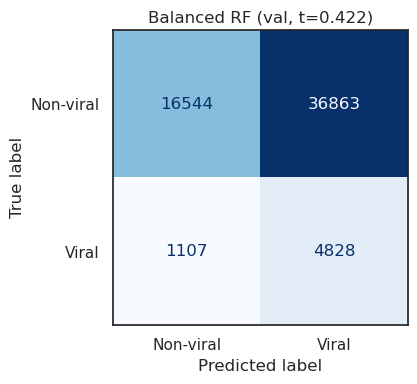

In [42]:
# # retrain best config on full training set
# print("\nRetraining best config on full training set...")
# rf_best = BalancedRandomForestClassifier(
#     **rf_grid.best_params_,
#     random_state=42,
#     n_jobs=1,
# )

rf_best = BalancedRandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=5,
    sampling_strategy='auto', random_state=42, n_jobs=1,
)
start = time.perf_counter()
rf_best.fit(X_train, y_train)
print(f"Full retrain done in {time.perf_counter() - start:.1f}s")

# evaluate on val
rf_proba     = rf_best.predict_proba(X_val)[:, 1]
rf_threshold = find_optimal_threshold(y_val, rf_proba)
rf_results   = evaluate_model('Balanced RF (val)', y_val, rf_proba, rf_threshold)
# rf_results.update({
#     'model':        'balanced_random_forest',
#     'split':        'val',
#     'best_params':  rf_grid.best_params_,
#     'cv_pr_auc':    round(rf_grid.best_score_, 4),
#     'note':         'grid search on 50k subsample, final model trained on full dataset',
# })

plot_confusion_matrix(y_val, rf_proba, rf_threshold,
                      f'Balanced RF (val, t={rf_threshold:.3f})',
                      '../results/rf_confusion_matrix.png')
# joblib.dump(rf_best, '../models/rf_best.pkl')

# with open('../results/rf_results.json', 'w') as f:
#     json.dump(rf_results, f, indent=2, default=str)
# print("Saved")

In [43]:
print("Feature stats:")
print(X_train.describe().round(3))
print("\nZero/near-zero variance features:")
print(X_train.std().sort_values().head(10))

Feature stats:
       title_word_count  day_of_week  time_of_day   emo_anger    emo_fear  \
count        564000.000   564000.000     564000.0  564000.000  564000.000   
mean              7.459        2.928          2.8       0.037       0.056   
std               5.639        1.979          1.5       0.099       0.141   
min               1.000        0.000          0.0       0.000       0.000   
25%               3.000        1.000          2.0       0.000       0.000   
50%               6.000        3.000          3.0       0.000       0.000   
75%              10.000        5.000          4.0       0.000       0.000   
max             553.000        6.000          5.0       1.000       1.000   

          emo_joy   emo_trust  emo_disgust  emo_sadness  emo_anticipation  \
count  564000.000  564000.000   564000.000   564000.000        564000.000   
mean        0.048       0.081        0.027        0.033             0.060   
std         0.109       0.177        0.089        0.097     

In [44]:
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("Feature-target correlations:")
print(correlations)

Feature-target correlations:
time_of_day          0.072157
is_fake              0.037173
factuality_mixed     0.017139
is_weekend           0.012013
day_of_week          0.009684
bias_left_center     0.008492
vader_compound       0.008157
bias_left            0.006685
emo_joy              0.004086
bias_right           0.003802
emo_surprise         0.003050
title_word_count     0.002938
bias_right_center    0.002832
emo_anger            0.002488
factuality_low       0.002345
emo_disgust          0.002279
emo_fear             0.002183
emo_anticipation     0.002172
emo_trust            0.001180
emo_sadness          0.001175
factuality_high      0.000699
bias_neutral         0.000647
hasImage                  NaN
dtype: float64


/opt/conda/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/conda/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [45]:
print("Viral distribution in each split:")
print(f"Train: {y_train.mean():.3f}")
print(f"Val:   {y_val.mean():.3f}")
print(f"Test:  {y_test.mean():.3f}")

# are viral posts actually different from non-viral on any feature?
print("\nMean feature values by virality:")
print(X_train.join(y_train).groupby('is_viral').mean().round(3).T)

Viral distribution in each split:
Train: 0.100
Val:   0.100
Test:  0.102

Mean feature values by virality:
is_viral               0      1
title_word_count   7.465  7.410
hasImage           1.000  1.000
day_of_week        2.922  2.986
is_weekend         0.262  0.280
time_of_day        2.836  2.475
emo_anger          0.037  0.037
emo_fear           0.056  0.055
emo_joy            0.048  0.046
emo_trust          0.081  0.081
emo_disgust        0.027  0.026
emo_sadness        0.032  0.033
emo_anticipation   0.060  0.059
emo_surprise       0.030  0.031
vader_compound     0.011  0.003
bias_left          0.008  0.010
bias_left_center   0.048  0.054
bias_neutral       0.022  0.021
bias_right_center  0.008  0.009
bias_right         0.006  0.007
factuality_high    0.060  0.060
factuality_mixed   0.030  0.040
factuality_low     0.001  0.002
is_fake            0.400  0.339


### 3.3 XGBoost with grid search

Barnes et al. use gradient boosting. Here using XGBoost, like Dogan et al. as a stronger model with `scale_pos_weight` for class imbalance

**JUSTIFY CHOICE OF XGBoost** - more recent, optimised version of sklearn's standard `GradientBoostingClassifier`. Why better? 
- Directly incoporates class imbalance into loss function using  `scale_pos_weight`
- Implements regularisation parameters (L1 alpha and L2 lambda) that reduce overfitting on high-dimensional feature spaces
- Faster on large datasets, allowing for grid search across wider hyperparamter space within constraints of GPU/time 
- Used in Redit virality prediciotn literature (Dogan et al., 2026)

Cite original XGBoost paper (Chen & Guestrin, 2016) for grid param value choices

scale_pos_weight: 8.99
XGBoost (val): optimal threshold=0.378
              precision    recall  f1-score   support

   Non-viral       0.93      0.23      0.37     53407
       Viral       0.11      0.86      0.19      5935

    accuracy                           0.29     59342
   macro avg       0.52      0.54      0.28     59342
weighted avg       0.85      0.29      0.35     59342

ROC-AUC:  0.6086
PR-AUC:   0.1478
Macro-F1: 0.2803


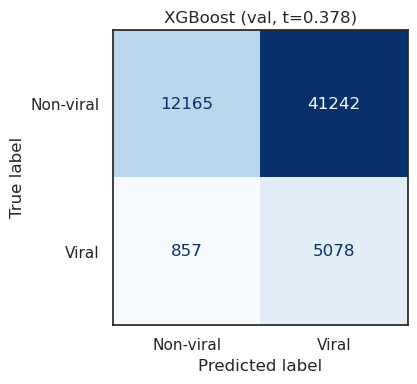

In [52]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # n_viral / n_non-viral
print(f'scale_pos_weight: {scale_pos_weight:.2f}')


# print('Grid search for XGBoost')
# xgb_param_grid = {
#     'max_depth':     [3, 6],
#     'learning_rate': [0.05, 0.1],
# }

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=1,
    eval_metric='aucpr',
    verbosity=0,
)

# xgb_grid = GridSearchCV(
#     xgb_base,
#     xgb_param_grid,
#     cv=cv,
#     scoring='average_precision',
#     n_jobs=1,
#     verbose=1,
# )

start = time.perf_counter()
xgb_base.fit(X_train, y_train)
# print(f"Done in {time.perf_counter() - start:.1f}s")
# print(f"Best params: {xgb_grid.best_params_}")
# print(f"Best val PR-AUC: {xgb_grid.best_score_:.4f}")

# xgb_best      = xgb_grid.best_estimator_
xgb_best = xgb_base # just use the base version for now without gird search
xgb_proba     = xgb_best.predict_proba(X_val)[:, 1]
xgb_threshold = find_optimal_threshold(y_val, xgb_proba)
xgb_results   = evaluate_model('XGBoost (val)', y_val, xgb_proba, xgb_threshold)
# xgb_results.update({
#     'model':             'xgboost',
#     'split':             'val',
#     'best_params':       xgb_grid.best_params_,
#     'cv_pr_auc':         round(xgb_grid.best_score_, 4),
#     'scale_pos_weight':  round(scale_pos_weight, 2),
# })

plot_confusion_matrix(y_val, xgb_proba, xgb_threshold,
                      f'XGBoost (val, t={xgb_threshold:.3f})',
                      '../results/xgb_confusion_matrix.png')

# with open('../results/xgb_results.json', 'w') as f:
#     json.dump(xgb_results, f, indent=2, default=str)
# print("Saved to ../results/xgb_results.json")


### 3.4 Model Evaluation

Virality classification has inherent class imbalance, raw "Accuracy" is a misleading metric (a dummy model guessing 0 every time would achieve ~91.5% accuracy). Instead prioritising: 

- ROC-AUC (Receiver Operating Characteristic - Area Under Curve): Measures the model's overall capability to cleanly separate viral content from non-viral content across all potential probability thresholds
- Precision-Recall AUC (PR-AUC): The definitive evaluation metric for imbalanced datasets, focusing exclusively on the model's performance regarding the minority Viral (1) class
- Confusion Matrix Breakdown: Analysis of precise operational performance at the optimal decision boundary:
- Precision: Out of all posts the model predicted would go viral, how many actually did? (Minimises false alarms)
- Recall (Sensitivity): Out of all posts that actually went viral, how many did the model successfully catch? (Minimizes missed opportunities)



#### 3.4.1 Precision-Recall curve comparison 

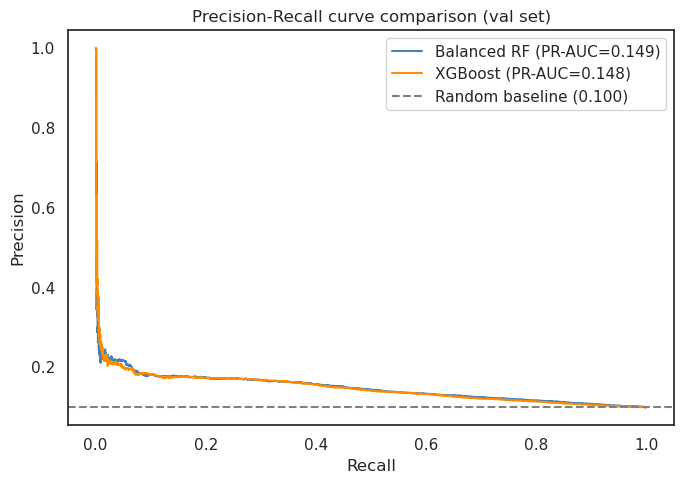

In [53]:
fig, ax = plt.subplots(figsize=(7, 5))
for proba, label, colour in [
    (rf_proba,  'Balanced RF', 'steelblue'),
    (xgb_proba, 'XGBoost',     'darkorange'),
]:
    p, r, _ = precision_recall_curve(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)
    ax.plot(r, p, colour, label=f'{label} (PR-AUC={pr_auc:.3f})')

baseline = y_val.mean()
ax.axhline(baseline, linestyle='--', color='grey',
           label=f'Random baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve comparison (val set)')
ax.legend()
plt.tight_layout()
plt.savefig('../results/pr_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4.2 RF and XGBoost summary table

In [54]:
summary = pd.DataFrame([rf_results, xgb_results])
print("\n=== Model comparison (val set) ===")
print(summary[['model', 'roc_auc', 'pr_auc',
               'macro_f1', 'optimal_threshold', 'cv_pr_auc']].to_string(index=False))

with open('../results/model_comparison.json', 'w') as f:
    json.dump([rf_results, xgb_results], f, indent=2, default=str)


=== Model comparison (val set) ===


KeyError: "['model', 'cv_pr_auc'] not in index"


### 4. Feature importance and interpretability

SHAP (SHapley Additive exPlanations): Deploy SHAP values across your trained XGBoost model. Uses cooperative game theory to measure the exact directional contribution of every feature toward a post's final virality score.

Can generate SHAP summary plots to answer core research questions e.g. influence of fake news, emotional language, topics, political leanining on Reddit post virality 


- **Lundberg & Lee (2017) — "A Unified Approach to Interpreting Model Predictions"**: Original SHAP paper. I'm using TreeSHAP (section 4)
    - SHAP values sum to the difference between the prediction and the mean prediction)
    - SHAP values are additive feature attributions that sum to the model's output
    - TreeSHAP is **exact** for tree-based models - not an approximation
    - Will generate beeswarm plot (section 5)  

- **Hashmi et al. (2024) — "Hybrid Deep Learning With FastText and Explainable AI"**: used SHAP on a misinformation task. Can read their SHAP section to see how they present their results. Global feature importance and per-class SHAP analysis

- **Mouratidis et al. (2025) - From Misinformation to Insight: Machine Learning Strategies for Fake News Detection** Very relevant recent paper (37 citations. Uses SHAP and LIME on XGBoost and Random Forest for fake news detection. This paper is also great for feature extraction ideas - they use stuff like misleading keyowrds, sentiment, and domain credibility in their SHAP analysis - **look into this**

- **Gongane et al. (2024) - "A survey of explainable AI techniques for detection of fake news and hate speech on social media platforms"** - survey of XAI for detection of hate speech and fake news on social media - can cite when saying that SHAP has become the standard XAI approach for fake news detection 

- Also useful
    - Read feature importance section of Barnes et al. Can see what they reported as important for meme virality. Potential comparison point for my SHAP findings
    - Not using XGBoost's native feature importance scores (gain, weight, coverage). SHAP paper shows that gain-based feature importance is less consistent. 

**US/Fakeddit SHAP** - core question is whether fake news plays a key role in virality 

Need the following:
- Global summary plot - where does `is_fake` sit relative to my other features? In top X? 
- SHAP dependence for `is_fake` - binary feature so two clusters of dots - are they in different places on the y-axis axis? Positive SHAP means pushed towards virality.
- Subgroup comparison - viral fake vs viral true vs non-viral fake vs non-viral true. Do they go viral for the same reasons? 

**TreeSHAP**

From original SHAP paper - method specific for XGBoost


Each feature has a value - contribution of that feature to pushing the prediction above/below the mean prediction

In [55]:
Path('../results/shap').mkdir(parents=True, exist_ok=True)

explainer   = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_val)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Mean prediction (base value): {explainer.expected_value:.4f}")

SHAP values shape: (59342, 23)
Mean prediction (base value): -0.0003


In [ ]:
import scipy.special

# convert SHAP log-odds sum to probability
shap_sum_logodds = shap_values[:5].sum(axis=1) + explainer.expected_value
shap_sum_proba = scipy.special.expit(shap_sum_logodds)  # sigmoid transform

print("Sanity check (should be close):")
print(f"Model proba:    {xgb_best.predict_proba(X_val[:5])[:, 1].round(3)}")
print(f"SHAP sum+base:  {shap_sum_proba.round(3)}")


Sanity check (should be close):
Model proba:    [0.507 0.378 0.437 0.471 0.456]
SHAP sum+base:  [ 0.028 -0.498 -0.253 -0.117 -0.176]


**Global summary plot**

Ranks features by mean SHAP

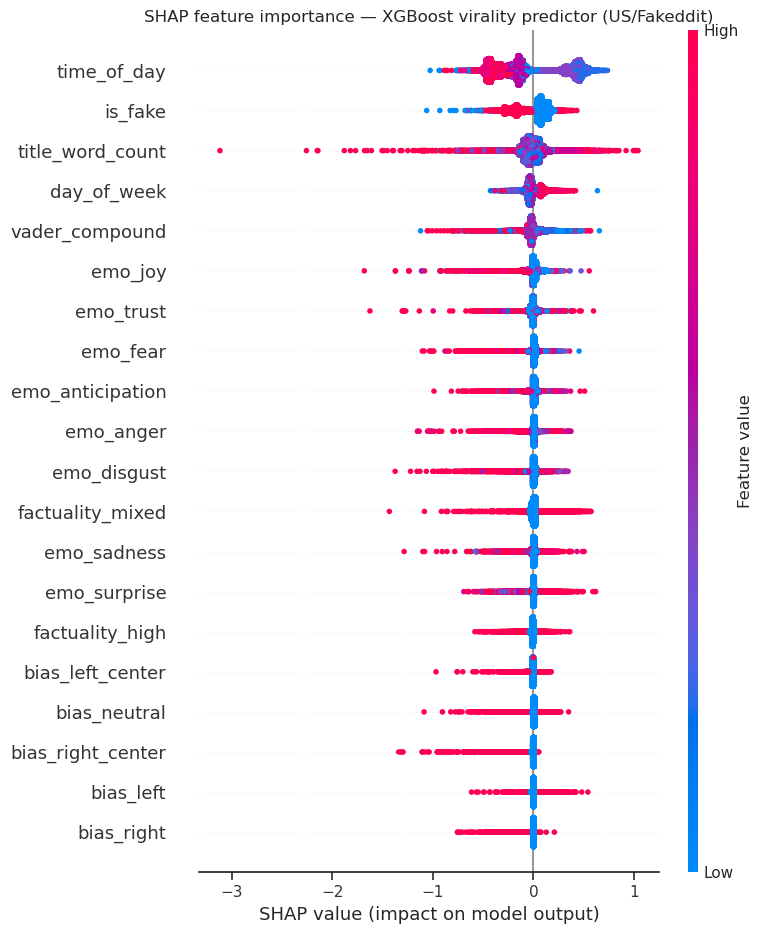

In [57]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_val,
    feature_names=FEATURE_COLS,
    show=False,
    max_display=20,
)
plt.title('SHAP feature importance — XGBoost virality predictor (US/Fakeddit)')
plt.tight_layout()
plt.savefig('../results/shap/summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()


**`is_fake` dependence plot**

For core quesiton - does fake news contribute to predicting virality? 

x axis - 0 or 1 (true content, fake content)
y axis - SHAP contribution to virality prediction


<Figure size 600x500 with 0 Axes>

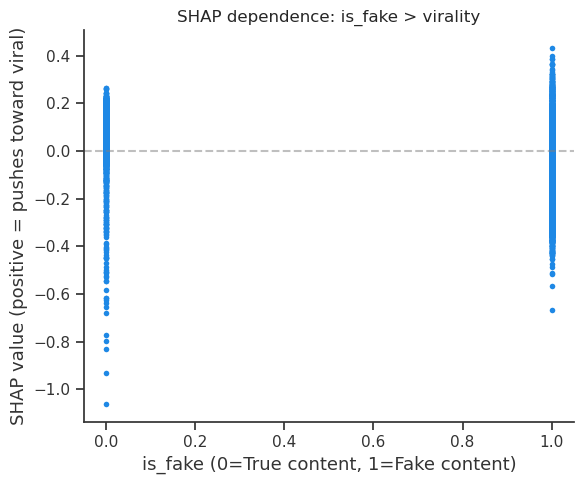

In [58]:
fake_idx = FEATURE_COLS.index('is_fake')

plt.figure(figsize=(6, 5))
shap.dependence_plot(
    'is_fake',
    shap_values,
    X_val,
    feature_names=FEATURE_COLS,
    interaction_index=None,   # no interaction colour so easy to interpret at first
    show=False,
)
plt.title('SHAP dependence: is_fake > virality')
plt.xlabel('is_fake (0=True content, 1=Fake content)')
plt.ylabel('SHAP value (positive = pushes toward viral)')
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../results/shap/is_fake_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
# mean SHAP for fake vs true posts
mean_shap_fake = shap_values[X_val['is_fake'] == 1, fake_idx].mean()
mean_shap_true = shap_values[X_val['is_fake'] == 0, fake_idx].mean()
print(f"\nMean SHAP for is_fake:")
print(f"  Fake posts (is_fake=1): {mean_shap_fake:+.4f}")
print(f"  True posts (is_fake=0): {mean_shap_true:+.4f}")
print(f"  Direction: {'fake content pushes TOWARDS viral' if mean_shap_fake > 0 else 'fake content pushes AWAY FROM viral'}")


Mean SHAP for is_fake:
  Fake posts (is_fake=1): -0.1679
  True posts (is_fake=0): +0.0911
  Direction: fake content pushes AWAY FROM viral


**Subgroup SHAP comparison**

Do viral fake and viral true posts go viral for the same reasons?

In [60]:
# classify val set into 4 groups 
y_pred_val = (xgb_proba >= xgb_threshold).astype(int)
is_fake_val = X_val['is_fake'].values

groups = {
    'Viral + Fake':     (y_pred_val == 1) & (is_fake_val == 1),
    'Viral + True':     (y_pred_val == 1) & (is_fake_val == 0),
    'Non-viral + Fake': (y_pred_val == 0) & (is_fake_val == 1),
    'Non-viral + True': (y_pred_val == 0) & (is_fake_val == 0),
}

print("\nMean SHAP values by group")
print(f"{'Feature':}", end='')

for g in groups: print(g)


group_shap = {}
for g, mask in groups.items():
    n = mask.sum()
    group_shap[g] = shap_values[mask].mean(axis=0)
    print(f"  n={n:,}", end='')
print()

# top features only for readability
top_feat_idx = np.argsort(np.abs(shap_values).mean(axis=0))[::-1][:10]

for i in top_feat_idx:
    fname = FEATURE_COLS[i]
    print(f"{fname:<25}", end='')
    for g in groups:
        print(f"{group_shap[g][i]:>+20.4f}", end='')
    print()

# save as dataframe
shap_group_df = pd.DataFrame(
    {g: group_shap[g] for g in groups},
    index=FEATURE_COLS,
)
shap_group_df.to_csv('../results/shap/group_shap_comparison.csv')
print("\nSaved to ../results/shap/group_shap_comparison.csv")


Mean SHAP values by group
FeatureViral + Fake
Viral + True
Non-viral + Fake
Non-viral + True
  n=14,402  n=31,918  n=8,918  n=4,104
time_of_day                           +0.0906             -0.0115             -0.2698             -0.3991
is_fake                               -0.1577             +0.0968             -0.1844             +0.0465
title_word_count                      +0.0415             -0.0081             -0.0640             -0.0981
day_of_week                           +0.0046             -0.0015             -0.0263             -0.0297
vader_compound                        +0.0056             -0.0058             -0.0358             -0.0727
emo_joy                               +0.0035             +0.0032             -0.0157             -0.0173
emo_trust                             -0.0003             -0.0037             -0.0125             -0.0231
emo_fear                              +0.0021             +0.0027             -0.0107             -0.0237
emo_anticipation   

**Feature importance table (mean SHAP)**

In [61]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature':       FEATURE_COLS,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False)

print("\nFeature importance (mean |SHAP|)")
print(importance_df.to_string(index=False))
importance_df.to_csv('../results/shap/feature_importance.csv', index=False)


Feature importance (mean |SHAP|)
          feature  mean_abs_shap
      time_of_day       0.325113
          is_fake       0.126667
 title_word_count       0.075756
      day_of_week       0.052472
   vader_compound       0.051908
          emo_joy       0.026110
        emo_trust       0.021154
         emo_fear       0.020012
 emo_anticipation       0.019398
        emo_anger       0.018900
      emo_disgust       0.018289
 factuality_mixed       0.015701
      emo_sadness       0.014300
     emo_surprise       0.014273
  factuality_high       0.012083
 bias_left_center       0.007591
     bias_neutral       0.007336
bias_right_center       0.005102
        bias_left       0.002271
       bias_right       0.001916
   factuality_low       0.001106
       is_weekend       0.000000
         hasImage       0.000000


## Summary of results

**Model performance**
- Both RF and XGBoost perform badly - this is likely a dataset characterisitc, rather than a model failure
- Fakeddit is image-driven - possible that textual and metadata features have minimal signals for predicting engagement

**Feature importance (global SHAP ranking**
- `time_of_day` is the dominant feature by a large margin - mean SHAP = 0.325). Finding that post time matters for virality is consistent with Barne et al (2020)
- `is_fake`is the second most imprtant feature (0.127). Strongest content-based signal, despit weak model performance
- `title_word_count` (0.076) is third. Small but consistent with Tsur & Rappoport (2012). Brevity = higher popularity
- Emotion features weak - expected result given stat significance test reuslts found in feature analysis
- MBFC domain credibility features are negligible but this is expected due to their 92% sparsity (majority of domains are reddit native)
- hasImage and is_weekend have 0 importance - error in weekend calculation and every post in fakeddit has an image so it's redundant. Should drop

**Directionality of `is_fake` - key finding**
- Fake content pushes away from virality (mean SHAP = -0.168 for fake posts vs +0.091 for true posts)
- This suggests that truw content is more likely to go viral than fake content on in the Fakeddit dataset
- Can see this in the sHAP dependence plot - true posts cluster above 0 line (around 0.2-0.25), false below (-0.4 to -0.5). Suppresion effect on fake greater than boost for truw
- Small number of fake posts have +ve SHAP values (seen in top right of plot) but overall direction is clearly negative
- **Why?** - due to the nature of the dataset. Posssible that the image-centric content of fakeddit (image manipulation, propaganda posters, satire)is engaged with differently from political misinformation. Virality mechnaism for genrral US meme contentmay differ from that of political misinfo. UK analysis on text-only, politcal reddits will help to investigate this


**Subgroup SHAP comparison (viral/non-viral and fake/true - 4 groups**
- time_of_day drives both viral groups but more strongly for viral fake (+0.091) than viral true (-0.012) — fake content's virality is more time-dependent
- is_fake shows consistent negative SHAP for fake posts regardless of virality outcome (-0.158 viral fake, -0.184 non-viral fake) — veracity suppresses virality across the board
- title_word_count positive for viral fake (+0.042), negative for viral true (-0.008) — longer titles help fake content slightly but hurt true content
- Emotion features show minimal differentiation between viral fake and viral true — emotion does not explain why fake posts specifically go viral on Fakeddit
- Key conclusion: viral fake and viral true posts do not go viral for meaningfully different reasons on Fakeddit. Both are primarily driven by time_of_day and title_word_count. Veracity acts as a consistent suppressor rather than a selective amplifier


**Meaning for next steps**
- US baseline: is_fake is the second most important feature but suppresses virality — fake content is less viral on a general US Reddit corpus
- This finding is coherent given Fakeddit's composition (85% image-manipulation and satire in the fake class) — the dataset was never designed to capture political misinformation virality
- Directly motivates the UK analysis: does veracity amplify virality in UK political Reddit, where fake content is text-driven and politically charged rather than image-based?
- BERT classifier justified: despite weak overall model performance, is_fake is the second most important predictor — veracity matters even here, and should matter more in a politically coherent corpus. Applying the BERT classifier to UK data to extract predicted veracity labels is therefore empirically motivated, not just assumed